Marcadores de Salud vs. Estrato
=======

Empezamos por analizar el efecto que tiene el estrato de una persona con su medicion de Colesterol LDL, Glucosa y Trigliceridos.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ztest

In [10]:
df = pd.read_csv("../data/clean_data2.csv")
df.head()

,Unnamed: 0,FOLIO_I,entidad,desc_ent,municipio,desc_mun,estrato,sexo,edad,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
0,3,2022_01001009,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,2,65,130.0,111.0,131.0
1,8,2022_01001013,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,1,35,107.0,106.0,297.0
2,13,2022_01001015,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,2,65,76.0,109.0,136.0
3,17,2022_01001024,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,2,30,84.0,98.0,121.0
4,19,2022_01001027,1,01 AGUASCALIENTES,1,001 AGUASCALIENTES,3,1,76,119.0,253.0,257.0


In [11]:
df['estrato'].value_counts()

estrato
3    932
2    599
1    560
Name: count, dtype: int64

In [12]:
df['estrato'] = df['estrato'].replace({2:1})
df['estrato'] = df['estrato'].replace({3:2})
df['estrato'].value_counts()

estrato
1    1159
2     932
Name: count, dtype: int64

In [29]:
df[df['estrato'] == 1][['valor_COL_LDL', 'valor_GLU_SUERO', 'valor_TRIG']].describe()

,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
count,1159.00000,1159.000000,1159.000000
mean,88.36126,105.229853,167.523727
std,29.86544,84.252463,126.881491
min,15.00000,10.400000,23.000000
25%,67.00000,80.000000,93.000000
50%,86.00000,90.000000,133.000000
75%,106.50000,102.000000,196.000000
max,269.00000,2372.000000,1320.000000


In [31]:
df[df['estrato'] == 2][['valor_COL_LDL', 'valor_GLU_SUERO', 'valor_TRIG']].describe()

,valor_COL_LDL,valor_GLU_SUERO,valor_TRIG
count,932.000000,932.000000,932.000000
mean,93.393562,102.950644,158.325107
std,31.687232,47.084467,127.367861
min,11.100000,46.000000,27.000000
25%,71.000000,81.000000,88.750000
50%,92.000000,90.000000,129.000000
75%,111.000000,102.000000,186.000000
max,303.000000,405.000000,1361.000000


In [40]:
col_ztest = ztest(df[df['estrato'] == 1]['valor_COL_LDL'], df[df['estrato'] == 2]['valor_COL_LDL'], value=0)
glu_ztest = ztest(df[df['estrato'] == 1]['valor_GLU_SUERO'], df[df['estrato'] == 2]['valor_GLU_SUERO'], value=0)
trig_ztest = ztest(df[df['estrato'] == 1]['valor_TRIG'], df[df['estrato'] == 2]['valor_TRIG'], value=0)

print(f"Colesterol mean difference test      z-value: {col_ztest[0]: .3f},   p-value: {col_ztest[1]: .5f}")
print(f"Glucose mean difference test         z-value: {glu_ztest[0]: .3f},   p-value: {glu_ztest[1]: .5f}")
print(f"Triglycerides mean difference test   z-value: {trig_ztest[0]: .3f},   p-value: {trig_ztest[1]: .5f}")

Colesterol mean difference test      z-value: -3.727,   p-value:  0.00019
Glucose mean difference test         z-value:  0.738,   p-value:  0.46032
Triglycerides mean difference test   z-value:  1.645,   p-value:  0.09998


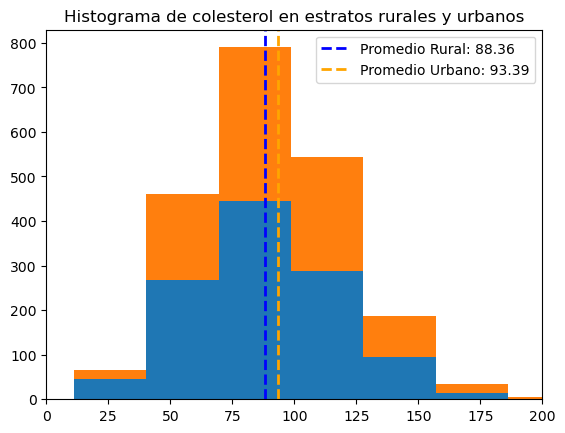

In [58]:
mean_1 = df[df['estrato'] == 1]['valor_COL_LDL'].mean()
mean_2 = df[df['estrato'] == 2]['valor_COL_LDL'].mean()
plt.hist([df[df['estrato'] == 1]['valor_COL_LDL'], df[df['estrato'] == 2]['valor_COL_LDL']], stacked=True)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.xlim(0, 200)
plt.legend()
plt.title('Histograma de colesterol en estratos rurales y urbanos')
plt.show()

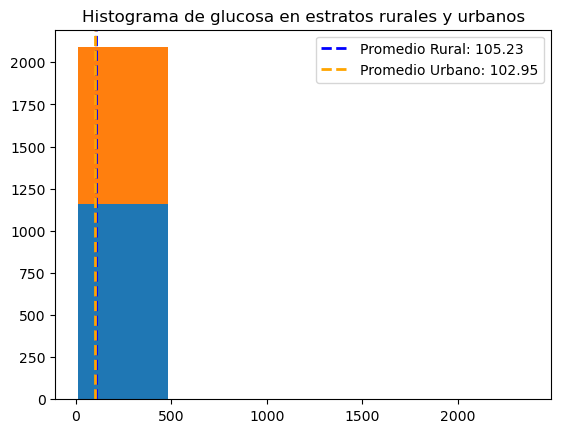

In [65]:
mean_1 = df[df['estrato'] == 1]['valor_GLU_SUERO'].mean()
mean_2 = df[df['estrato'] == 2]['valor_GLU_SUERO'].mean()
plt.hist([df[df['estrato'] == 1]['valor_GLU_SUERO'], df[df['estrato'] == 2]['valor_GLU_SUERO']], stacked=True, bins=5)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.legend()
plt.title('Histograma de glucosa en estratos rurales y urbanos')
plt.show()

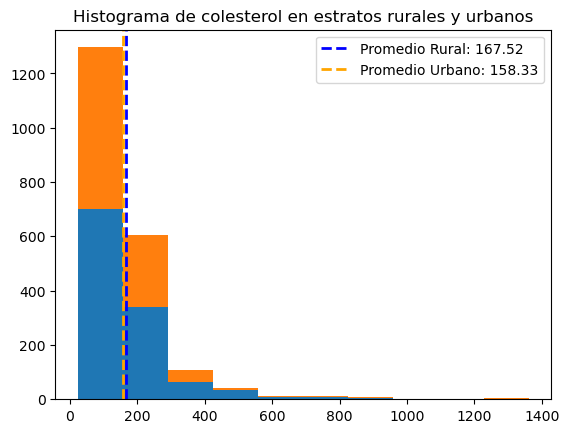

In [66]:
mean_1 = df[df['estrato'] == 1]['valor_TRIG'].mean()
mean_2 = df[df['estrato'] == 2]['valor_TRIG'].mean()
plt.hist([df[df['estrato'] == 1]['valor_TRIG'], df[df['estrato'] == 2]['valor_TRIG']], stacked=True)
plt.axvline(mean_1, color='b', linestyle='dashed', linewidth=2, label=f'Promedio Rural: {mean_1:.2f}')
plt.axvline(mean_2, color='orange', linestyle='dashed', linewidth=2, label=f'Promedio Urbano: {mean_2:.2f}')
plt.legend()
plt.title('Histograma de colesterol en estratos rurales y urbanos')
plt.show()

AttributeError: Line2D.set() got an unexpected keyword argument 'linetype'

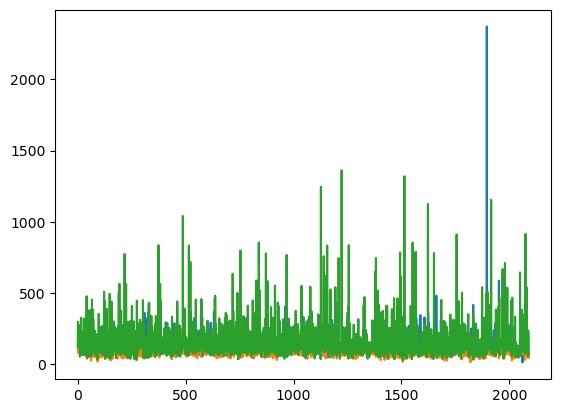

In [77]:
plt.plot(df['valor_GLU_SUERO'])
plt.plot(df['valor_COL_LDL'])
plt.plot(df['valor_TRIG'])
plt.axvline(df['valor_GLU_SUERO'].argmax(), color='r', linetype='dashed')